### Imports

In [1]:
#imports 
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

# pour avoir des resultats reproductibles
SEED = 42
np.random.seed(SEED)         # Celui de  NumPy 
torch.manual_seed(SEED)      # Celui de Pytorch

### 1. Chargement et préparation des données
- Nous commençons par charger les trajectoires
- On construit les labels
- 

In [2]:
# --- 1. Chargement et préparation des données ---
# Charger les trajectoires des 2 classes
data_class1 = np.load("class1_trajectories.npy")  
data_class2 = np.load("class2_trajectories.npy")  
# On ajoute la 3eme classe manquante
data_class3 = np.load("class3_trajectories.npy")
data = np.concatenate((data_class1, data_class2, data_class3))    
    
# Construction des labels ---
labels = np.concatenate((np.zeros(data_class1.shape[0]), np.ones(data_class2.shape[0]), 2*np.ones(data_class3.shape[0])))

### 2. Split train/val/test set

In [ ]:
# --- 2. Split train/val/test ---
n_samples = data.shape[0]
indices = np.arange(n_samples)
np.random.seed(30) # on initialise le seed pour que les resultats soient reproductibles

np.random.shuffle(indices)  # on melange les indices

train_size = int(0.8 * n_samples) # on calcule la taille des set
val_size = int(0.1 * n_samples) 
test_size = n_samples - train_size - val_size 

train_indices = indices[:train_size]
val_indices = indices[train_size:train_size+val_size]
test_indices = indices[train_size+val_size:] 

train_data = data[train_indices]
train_labels = labels[train_indices] 
val_data = data[val_indices]
val_labels = labels[val_indices]
test_data = data[test_indices]
test_labels = labels[test_indices]

#### 3. Normalisation eventuelle
- nous devons normalizer les données pour que les trajectoires soient comparables et bien sur stabiliser et eviter unstable training 
- pour cela nous utilisons z score normalization : https://www.geeksforgeeks.org/data-analysis/z-score-normalization-definition-and-examples/ cette normalization centre les données et les reduit a une variance de 1
- Pour chaque trajectoire, nous calculons la moyenne et l'ecart type
- On normalise les données en subtractant la moyenne et en divisant par l'écart type
- On peut aussi essayer min-max normalization : https://medium.com/@abhi1achiever/min-max-normalization-db1f515b08b4


In [ ]:
#on reshape les données pour que chaque trajectoire soit une seule ligne
train_flat = train_data.reshape(-1, train_data.shape[-1])
#on calcule la moyenne et l'écart type de chaque trajectoire
mean = train_flat.mean(axis=0)
std = train_flat.std(axis=0)
std = np.where(std == 0, 1e-6, std) #pour eviter la division par 0 (RuntimeWarning: invalid value encountered in divide)

#on essaie d'abord de normaliser les données
train_normalized = (train_data - mean)/std 
val_normalized = (val_data - mean)/std
test_normalized = (test_data - mean)/std




#### 4. Data augmentation 
- Comment augmenter sans fausser les données? 

In [5]:
#TODO data augmentation 

#### 4.  data pytorch pour la classification

In [6]:

# --- 3. Dataset PyTorch pour la classification ---
class TrajectoryClassificationDataset(Dataset):
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):# pour récupérer un échantillon (x, y) dans le dataset
        x = self.data[idx]
        y = self.labels[idx] #on prend le label de l'echantillon
        return torch.FloatTensor(x), torch.LongTensor([y])

#### Création des datasets et dataloaders

In [7]:
# On crée les datasets
train_dataset = TrajectoryClassificationDataset(train_normalized, train_labels)
val_dataset = TrajectoryClassificationDataset(val_normalized, val_labels)
test_dataset = TrajectoryClassificationDataset(test_normalized, test_labels)

# On créé les DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

#### 4. Modèle pour la classification

In [8]:
class MonModele(nn.Module):
    def __init__(self, input_size=20, hidden_size = 64, num_layers=2, output_size=3, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.dropout = nn.Dropout(0.2) # pour eviter le surapprentissage
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x, _ = self.lstm(x) #nous donne la sortie de la derniere couche LSTM
        x = self.dropout(x) #applique dropout
        x = self.fc(x[:, -1, :]) #nous donne la sortie de la derniere couche FC
        return x

#### fonctions helpers

In [ ]:
#fonction pour calculer la norme du gradient
#on calcule la norme du gradient pour visualiser l'exploding gradient

def grad_norm_cal(model): 
    total_norm = 0.0
    for i in model.parameters(): # on parcourt les paramètres du modèle
        if i.grad is None: # si le gradient est None, on passe au suivant
            continue
        param_norm = i.grad.data.norm(2).item() # on calcule la norme du gradient
        total_norm += param_norm ** 2
    total_norm = total_norm ** 0.5 
    return total_norm

#### 5.Instanciation

In [10]:
model = MonModele(input_size=20, hidden_size = 64, num_layers=2, output_size=3, dropout=0.2)
criterion = nn.CrossEntropyLoss() #nous utilisons la fonction de perte CrossEntropyLoss
optimizer = optim.Adam(model.parameters(), lr=0.001) #nous utilisons l'optimiseur Adam

n_epochs = 40 #nous utilisons 40 epochs pour l'entrainement
train_losses, val_losses = [], []
train_accs, val_accs = [], []

#### Entrainement


In [11]:
#grad_norms = []
for epoch in range(n_epochs):
    model.train()
    epoch_train_loss = 0
    correct = 0
    total = 0
    for x_batch, y_batch in train_loader:
        y_batch = y_batch.squeeze()  #nous transformons les labels en 1D (pour eviter RuntimeError: 0D or 1D target tensor expected)
        optimizer.zero_grad()
        #on calcule la prediction
        y_pred = model(x_batch) 
        #nous calculons la fonction de perte
        loss = criterion(y_pred, y_batch) 
        #on calcule le gradient de la fonction de perte
        loss.backward() 
        # on applique la technique de gradient clipping pour eviter l'exploding gradient 
        # https://docs.pytorch.org/docs/stable/generated/torch.nn.utils.clip_grad_norm_.html
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # 
        
        #on calcule la norme du gradient pour visualiser l'exploding gradient
        #grad_norms.append(grad_norm_cal(model))

        #on met a jour les parametres du modele
        optimizer.step() 
        #nous sommons les pertes moyennes pour chaque batch
        epoch_train_loss += loss.item() * x_batch.size(0) #on multiplie par le nombre d'echantillons pour avoir la moyenne par rapport au nombre d'echantillons
        #on donne la prediction du modele
        _, predicted = torch.max(y_pred.data, 1) 
        #on ajoute le nombre d'echantillons a la liste des total
        total += y_batch.size(0) 
        #on compte le nombre de prédictions correctes et les additionnons dans le compteur "correct"
        correct += (predicted == y_batch.squeeze()).sum().item() 
    train_losses.append(epoch_train_loss / total) #nous calculons la moyenne des loss par époque d'entrainement et l'ajoutons à la liste des train_losses
    train_accs.append(100 * correct / total) #nous calculons l'accuracy = taux de bonnes prédictions totales de l'époque et l'ajoutons à la liste correspondante
    # Validation
    model.eval()
    epoch_val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            #on transforme les labels en 1D (pour eviter RuntimeError: 0D or 1D target tensor expected)
            y_batch = y_batch.squeeze() 
            #on calcule la prediction
            y_pred = model(x_batch) 
            #on calcule la fonction de perte
            loss = criterion(y_pred, y_batch) 
            epoch_val_loss += loss.item() #nous sommons les pertes moyennes pour chaque batch
            _, predicted = torch.max(y_pred.data, 1) #nous donne la prediction du modele
            total += y_batch.size(0) #nous ajoutons le nombre d'echantillons a la liste des total
            correct += (predicted == y_batch.squeeze()).sum().item() #nous comptons le nombre de prédictions correctes et les additionnons dans le compteur "correct"
    val_losses.append(epoch_val_loss / len(val_loader)) #nous calculons la moyenne des loss par époque de validation et l'ajoutons à la liste des train_losses
    val_accs.append(100 * correct / total) #nous calculons l'accuracy = taux de bonnes prédictions totales de l'époque et l'ajoutons à la liste correspondante

    print(f"Epoch {epoch+1}/{n_epochs}, Train loss: {train_losses[-1]:.4f}, Val loss: {val_losses[-1]:.4f}, Train Acc: {train_accs[-1]:.2f}%, Val Acc: {val_accs[-1]:.2f}%")

Epoch 1/40, Train loss: 1.0969, Val loss: 1.0943, Train Acc: 29.48%, Val Acc: 32.89%
Epoch 2/40, Train loss: 1.0598, Val loss: 0.8520, Train Acc: 51.79%, Val Acc: 60.53%
Epoch 3/40, Train loss: 0.8828, Val loss: 0.6059, Train Acc: 57.00%, Val Acc: 57.89%
Epoch 4/40, Train loss: 0.5710, Val loss: 0.4749, Train Acc: 63.19%, Val Acc: 75.00%
Epoch 5/40, Train loss: 0.4937, Val loss: 0.4670, Train Acc: 65.31%, Val Acc: 61.84%
Epoch 6/40, Train loss: 0.4795, Val loss: 0.4445, Train Acc: 64.98%, Val Acc: 75.00%
Epoch 7/40, Train loss: 0.4718, Val loss: 0.4541, Train Acc: 67.59%, Val Acc: 61.84%
Epoch 8/40, Train loss: 0.4751, Val loss: 0.5043, Train Acc: 65.80%, Val Acc: 64.47%
Epoch 9/40, Train loss: 0.5354, Val loss: 0.4376, Train Acc: 68.24%, Val Acc: 76.32%
Epoch 10/40, Train loss: 0.4692, Val loss: 0.4318, Train Acc: 70.85%, Val Acc: 76.32%
Epoch 11/40, Train loss: 0.4475, Val loss: 0.4720, Train Acc: 79.80%, Val Acc: 77.63%
Epoch 12/40, Train loss: 0.6469, Val loss: 0.3990, Train Acc: 7

#### Visualisation

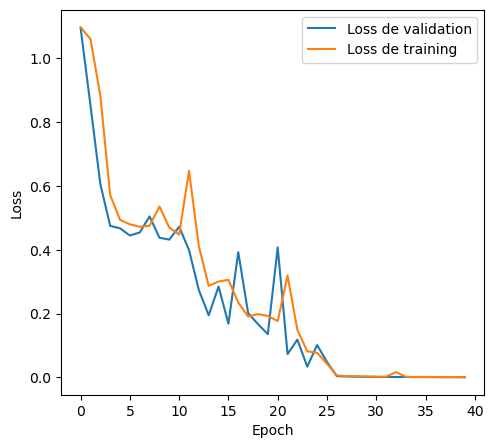

In [17]:
def visualize_validation(val_losses, train_losses):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(val_losses, label='Loss de validation')
    plt.plot(train_losses, label='Loss de training')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
visualize_validation(val_losses, train_losses)

#### 7. Evaluation sur le test set

In [26]:
def evaluate_on_test(model, test_loader, criterion):
    model.eval() # on evalue le modele
    epoch_test_loss = 0 # on initialise la perte pour le test set , la liste des prédictions etc
    correct = 0 
    total = 0 
    all_predictions = [] 
    all_labels = [] 


    
    with torch.no_grad(): # pour ne pas calculer les gradients
        for x_batch, y_batch in test_loader: # on parcourt le test set
            y_batch = y_batch.squeeze() # on transforme les labels en 1D
            y_pred = model(x_batch) # on calcule les predictions
            loss = criterion(y_pred, y_batch) # on calcule la perte
            epoch_test_loss += loss.item() 
            
            
            _, predicted = torch.max(y_pred.data, 1) # on prend la prediction avec la valeur la plus élevée
            total += y_batch.size(0) # on ajoute le nombre d'echantillons à la variable total
            correct += (predicted == y_batch).sum().item() # on ajoute le nombre de bonnes predictions à la variable correct
            
            all_predictions.extend(predicted.numpy()) # on ajoute les predictions à la liste all_predictions
            all_labels.extend(y_batch.numpy()) # on ajoute les labels à la liste all_labels
    
    accuracy = 100 * correct / total
    avg_loss = epoch_test_loss / len(test_loader)
    
    print(f"results sur le test set ")
    print(f"Test loss: {avg_loss:.4f}")
    print(f"Test accu: {accuracy:.2f}%")
    print(f"Correct: {correct}/{total}")    
    return accuracy, avg_loss, all_predictions, all_labels

#### l'evaluation


In [ ]:
test_acc, test_loss, predictions, true_labels = evaluate_on_test(model, test_loader, criterion) # on evalue le modele sur le test set (pas un fichier externe)
"""
plt.plot(grad_norms)
plt.xlabel("step")
plt.ylabel("grad norm")
plt.title("norme du gradient")
plt.show()
"""


results sur le test set 
Test loss: 0.0007
Test accu: 100.00%
Correct: 78/78


'\nplt.plot(grad_norms)\nplt.xlabel("step")\nplt.ylabel("grad norm")\nplt.title("norme du gradient")\nplt.show()\n'

## Test Set externe


In [ ]:
def evaluate_external_test_set(model, mean, std, file_paths, labels, batch_size=32):
# on evalue le modele sur un test set externe
# on normalise avec la moyenne et l'ecart type du train set
# on utilise un dataloader pour le test set
# on peut utiliser un seul fichier ou plusieurs fichiers (un par classe) (pour un fichier, il faut un autre fichier pour les labels)
# on retourne la precision, la perte et les predictions et les labels
    if isinstance(file_paths, str):
        # Un seul fichier
        ext_data = np.load(file_paths) # on charge le fichier
        ext_labels = np.load(labels) if isinstance(labels, str) else np.array(labels) # on charge les labels
    else:
        # Plusieurs fichiers (un par classe)
        all_data, all_labels = [], [] # on initialise les listes pour les données et les labels
        for path, label in zip(file_paths, labels): # on parcourt les fichiers et les labels
            d = np.load(path) # on charge le fichier
            all_data.append(d) # on ajoute les données à la liste
            all_labels.append(np.full(d.shape[0], label)) # on ajoute les labels à la liste
        ext_data = np.concatenate(all_data) # on concatine les données
        ext_labels = np.concatenate(all_labels) # on concatine les labels

    # Normalisation + DataLoader
    ext_normalized = (ext_data - mean) / std  # on normalise les données pour que les trajectoires soient comparables avec celles utilisées pour le train
    ext_loader = DataLoader(TrajectoryClassificationDataset(ext_normalized, ext_labels), batch_size=batch_size, shuffle=False) # on crée un dataloader pour le test set
    # Évaluation
    model.eval() # on evalue le modele
    all_preds, all_true = [], [] # on initialise les listes pour les predictions et les labels
    correct, total, total_loss = 0, 0, 0.0 # on initialise les variables pour le nombre de bonnes predictions, le nombre total d'echantillons et la perte
    criterion = nn.CrossEntropyLoss() # on initialise la fonction de perte
    with torch.no_grad(): # pour ne pas calculer les gradients
        for x_batch, y_batch in ext_loader: # on parcourt le test set
            y_batch = y_batch.squeeze() # on transforme les labels en 1D
            y_pred = model(x_batch) # on calcule les predictions
            _, predicted = torch.max(y_pred, 1) # on prend la prediction avec la valeur la plus élevée
            loss = criterion(y_pred, y_batch) # on calcule la perte
            total_loss += loss.item() # on ajoute la perte à la variable total_loss
            correct += (predicted == y_batch).sum().item() # on ajoute le nombre de bonnes predictions à la variable correct
            total += y_batch.size(0) # on ajoute le nombre d'echantillons à la variable total
            all_preds.extend(predicted.numpy()) # on ajoute les predictions à la liste all_preds
            all_true.extend(y_batch.numpy()) # on ajoute les labels à la liste all_true

    acc = 100 * correct / total # on calcule la precision
    avg_loss = total_loss / len(ext_loader) # on calcule la perte moyenne
    print(f"loss sur le test set: {avg_loss:.4f}, precision: {acc:.2f}% ({correct}/{total})") # on affiche la precision et la perte
    return acc, avg_loss, np.array(all_preds), np.array(all_true)

In [ ]:
# test avec nos  données 
#files = ["class1_trajectories.npy", "class2_trajectories.npy", "class3_trajectories.npy"]
#acc, loss, preds, true = evaluate_external_test_set(model, mean, std, files, [0, 1, 2])

# Pour le test set :
# Plusieurs fichiers (un par classe) :
# acc, loss, preds, true = evaluate_external_test_set(model, mean, std, ["test_c1.npy", "test_c2.npy", "test_c3.npy"], [0, 1, 2])



# Un seul fichier + labels :
# acc, loss, preds, true = evaluate_external_test_set(model, mean, std, "test_data.npy", "test_labels.npy")